In [ ]:
!pip install numpy pandas statsmodels matplotlib wbgapi -q

# -- Librerias -------------------------------------------------------
import wbgapi as wb
import pandas as pd
import numpy as np
from statsmodels.tsa.filters.hp_filter import hpfilter
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from IPython.display import display
from scipy.optimize import differential_evolution
import warnings


Economía SIN Inversión: corr(CA/PIB, ciclo) = +0.318 [R1]
Economía CON Inversión: corr(CA/PIB, ciclo) = -0.033 [R2]



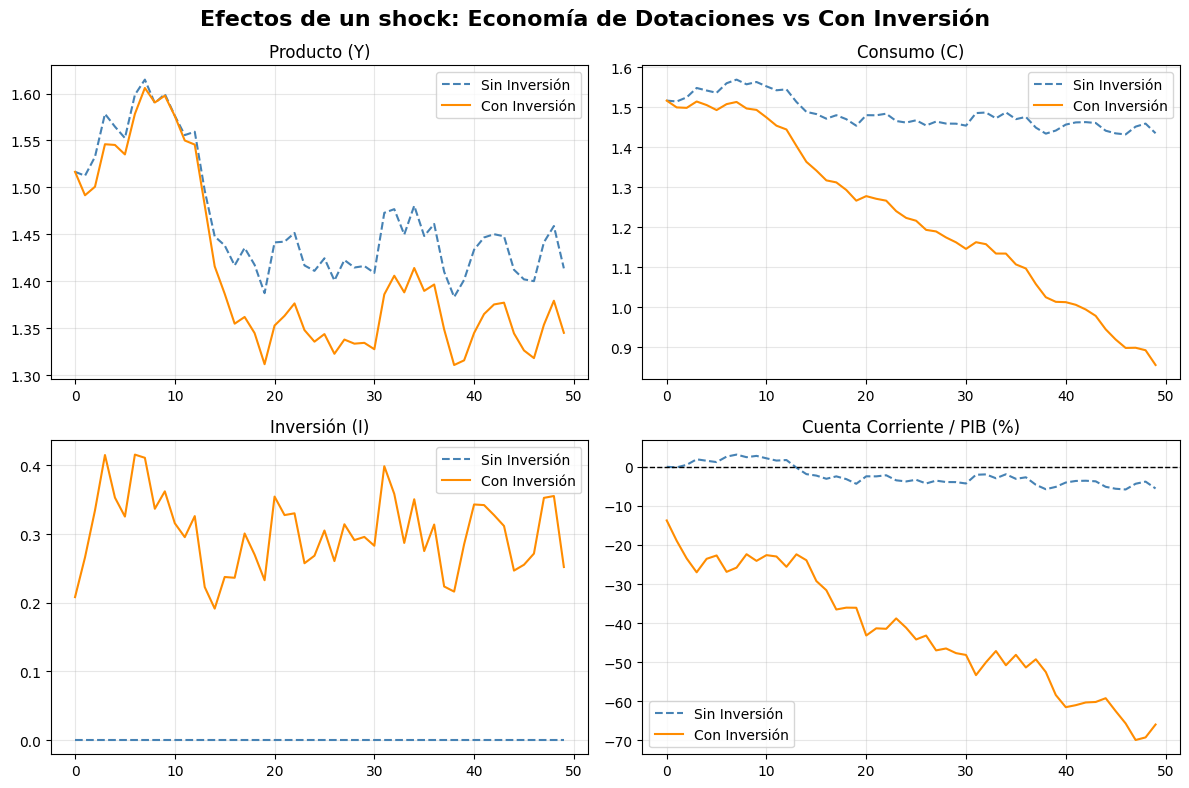



La economia con Cuenta Corriente procíclica es la economía con dotaciones y sin inversión (R1),
mientras que la economía con inversión es contracíclica (R2). Esto se debe a que si el pais con dotaciones sufre un shock positivo,
al no tener como invertir el excendente en maquiarias locales, el único canal que le queda es la suavizacion del consumo;
ya que el pais decidira ahorrar esa ganancia extra en el extranjero, se genera una Cuenta Corriente positiva (CA prociclica).

Por otro lado, cuando el canal de inversion se "enciende" (R2). El mismo shock positivo hace que invertir en el pais sea rentable.
Las empresas por consecuencia, en vez de ahorrar en el extranjero, invierten en la compra de maquinaria local.
Superando fuertemente al ahorro interno, obligando al pais a endeudarse con el resto del mundo para financiar este aumento en la
inversion local, lo cual por consiguiente, provoca un déficit de Cuenta Corriente (CA contracíclica).




In [3]:

# BLOQUE B

# PREGUNTA 24

# FUNCION -------------------------------------------------------------------

def simular_economia(alpha=0.33, beta=0.96, delta=0.10, r_star=0.04,
                     rho=0.90, sigma_eps=0.02, T=50, seed=42,
                     con_inversion=True):
    """
    Simula una economia pequena y abierta por T periodos.
    con_inversion=True: economia con produccion y capital.
    con_inversion=False: economia de dotaciones puras.
    """

    np.random.seed(seed)

    eps = np.random.normal(0, sigma_eps, T)
    ln_A = np.zeros(T)
    for t in range(1, T):
        ln_A[t] = rho * ln_A[t-1] + eps[t]
    A = np.exp(ln_A)

    k_ss = (alpha / (1/beta - 1 + delta)) ** (1/(1 - alpha))
    y_ss = k_ss ** alpha
    c_ss = y_ss - delta * k_ss

    k = np.zeros(T+1)
    y = np.zeros(T)
    c = np.zeros(T)
    i = np.zeros(T)
    b = np.zeros(T+1)

    k[0] = k_ss
    b[0] = 0

    for t in range(T):
        y[t] = (A[t] * k[t]**alpha) if con_inversion else (y_ss * A[t])

        if con_inversion:
            k_opt = (alpha * A[t] / (r_star + delta)) ** (1/(1 - alpha))
            k[t+1] = 0.5 * k_opt + 0.5 * (1 - delta) * k[t]
            i[t] = k[t+1] - (1 - delta) * k[t]
        else:
            k[t+1] = k[t]
            i[t] = 0

        c[t] = (1/(1 + beta)) * (y[t] + r_star * b[t] + beta * y_ss)
        b[t+1] = (1 + r_star) * b[t] + y[t] - c[t] - i[t]

    CA = b[1:] - b[:-1]
    TB = y - c - i
    S = y + r_star * b[:-1] - c

    return pd.DataFrame({
        'Y': y,
        'C': c,
        'I': i,
        'S': S,
        'CA': CA,
        'TB': TB,
        'CA_Y': CA/y * 100,
        'TB_Y': TB/y * 100,
        'I_Y': i/y * 100,
        'S_Y': S/y * 100
    })

# CODIGO -------------------------------------------------------------------

# 1. Simulamos ambas economias

df_dot = simular_economia(con_inversion=False, seed=42)
df_inv = simular_economia(con_inversion=True, seed=42)

# 2. Extraemos el ciclo del PIB para ambas economias
cycle_dot, _ = hpfilter(x=np.log(df_dot['Y']), lamb=6.25)
cycle_inv, _ = hpfilter(x=np.log(df_inv['Y']), lamb=6.25)

# 3. Calculamos la correlación entre CA/PIB y el ciclo del PIB
corr_ca_dot = cycle_dot.corr(df_dot['CA_Y'])
corr_ca_inv = cycle_inv.corr(df_inv['CA_Y'])

# 4. Mostramos los resultados
print(f"Economía SIN Inversión: corr(CA/PIB, ciclo) = {corr_ca_dot:+.3f} [R1]")
print(f"Economía CON Inversión: corr(CA/PIB, ciclo) = {corr_ca_inv:+.3f} [R2]")

# GRAFICO -------------------------------------------------------------------

# Configuracion del grafico
fig, axs = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Efectos de un shock: Economía de Dotaciones vs Con Inversión', fontsize=16, fontweight='bold')

# Gráfico 1: Producto (Y)
axs[0, 0].plot(df_dot['Y'], label='Sin Inversión', linestyle='--', color='steelblue')
axs[0, 0].plot(df_inv['Y'], label='Con Inversión', color='darkorange')
axs[0, 0].set_title('Producto (Y)')
axs[0, 0].grid(alpha=0.3)
axs[0, 0].legend()

# Gráfico 2: Consumo (C)
axs[0, 1].plot(df_dot['C'], label='Sin Inversión', linestyle='--', color='steelblue')
axs[0, 1].plot(df_inv['C'], label='Con Inversión', color='darkorange')
axs[0, 1].set_title('Consumo (C)')
axs[0, 1].grid(alpha=0.3)
axs[0, 1].legend()

# Gráfico 3: Inversión (I)
axs[1, 0].plot(df_dot['I'], label='Sin Inversión', linestyle='--', color='steelblue')
axs[1, 0].plot(df_inv['I'], label='Con Inversión', color='darkorange')
axs[1, 0].set_title('Inversión (I)')
axs[1, 0].grid(alpha=0.3)
axs[1, 0].legend()

# Gráfico 4: CA/PIB
axs[1, 1].plot(df_dot['CA_Y'], label='Sin Inversión', linestyle='--', color='steelblue')
axs[1, 1].plot(df_inv['CA_Y'], label='Con Inversión', color='darkorange')
axs[1, 1].axhline(0, color='black', linewidth=1, linestyle='--')
axs[1, 1].set_title('Cuenta Corriente / PIB (%)')
axs[1, 1].grid(alpha=0.3)
axs[1, 1].legend()

print()
plt.tight_layout()
plt.show()


comentario = """
La economia con Cuenta Corriente procíclica es la economía con dotaciones y sin inversión (R1),
mientras que la economía con inversión es contracíclica (R2). Esto se debe a que si el pais con dotaciones sufre un shock positivo,
al no tener como invertir el excendente en maquiarias locales, el único canal que le queda es la suavizacion del consumo;
ya que el pais decidira ahorrar esa ganancia extra en el extranjero, se genera una Cuenta Corriente positiva (CA prociclica).

Por otro lado, cuando el canal de inversion se "enciende" (R2). El mismo shock positivo hace que invertir en el pais sea rentable.
Las empresas por consecuencia, en vez de ahorrar en el extranjero, invierten en la compra de maquinaria local.
Superando fuertemente al ahorro interno, obligando al pais a endeudarse con el resto del mundo para financiar este aumento en la
inversion local, lo cual por consiguiente, provoca un déficit de Cuenta Corriente (CA contracíclica).

"""

print(f'\n{comentario}')

In [4]:
# PARTE 25

# VALORES ---------------------------------------------------------------------

# Definimos los valores
valores_rho = [0.3, 0.7, 0.95]
valores_alpha = [0.15, 0.33, 0.50]
valores_rstar = [0.02, 0.04, 0.08]

# Extras que añadi para poder analizar los efectos de sus cambios
valores_sigma_eps = [0.02, 0.06, 0.1]
valores_beta = [0.5, 0.8, 0.96]

# CODIGO ---------------------------------------------------------------------

# Se usa .std para poder capturar la volatilidad de la variable (para casos practicos, si la volatilidad sube, la variacion sube)

print("\n--- EFECTO DE AUMENTAR RHO (Persistencia del Shock) CON INVERSION ---")
for val in valores_rho:
    df = simular_economia(rho=val, con_inversion=True, seed=42)
    print(f"Rho = {val:<4} | Volatilidad Inversión (I): {df['I'].std():.4f} | Volatilidad CA: {df['CA'].std():.4f}")

print("\n--- EFECTO DE AUMENTAR ALPHA (Participación del capital) CON INVERSION ---")
for val in valores_alpha:
    df = simular_economia(alpha=val, con_inversion=True, seed=42)
    print(f"Alpha = {val:<4} | Volatilidad Inversión (I): {df['I'].std():.4f} | Volatilidad CA: {df['CA'].std():.4f}")

print("\n--- EFECTO DE AUMENTAR R* (Tasa de interés mundial) CON INVERSION ---")
for val in valores_rstar:
    df = simular_economia(r_star=val, con_inversion=True, seed=42)
    print(f"r* = {val:<4} | Volatilidad Inversión (I): {df['I'].std():.4f} | Volatilidad CA: {df['CA'].std():.4f}")

print("\n--- EFECTO DE AUMENTAR SIGMA_EPS (Potencia del Shock) CON INVERSION ---")
for val in valores_sigma_eps:
    df = simular_economia(sigma_eps=val, con_inversion=True, seed=42)
    print(f"Sigma_eps = {val:<4} | Volatilidad Inversión (I): {df['I'].std():.4f} | Volatilidad CA: {df['CA'].std():.4f}")

print("\n--- EFECTO DE AUMENTAR BETA (Paciencia de las Familias) CON INVERSION ---")
for val in valores_beta:
    df = simular_economia(beta=val, con_inversion=True, seed=42)
    print(f"Beta = {val:<4} | Volatilidad Inversión (I): {df['I'].std():.4f} | Volatilidad CA: {df['CA'].std():.4f}")

print("\n\n\n\n--- EFECTO DE AUMENTAR RHO (Persistencia del shock) SIN INVERSION ---")
for val in valores_rho:
    df = simular_economia(rho=val, con_inversion=False, seed=42)
    print(f"Rho = {val:<4} | Volatilidad Inversión (I): {df['I'].std():.4f} | Volatilidad CA: {df['CA'].std():.4f}")

print("\n--- EFECTO DE AUMENTAR ALPHA (Participación del capital) SIN INVERSION ---")
for val in valores_alpha:
    df = simular_economia(alpha=val, con_inversion=False, seed=42)
    print(f"Alpha = {val:<4} | Volatilidad Inversión (I): {df['I'].std():.4f} | Volatilidad CA: {df['CA'].std():.4f}")

print("\n=== EFECTO DE AUMENTAR R* (Tasa de interés mundial) SIN INVERSION ---")
for val in valores_rstar:
    df = simular_economia(r_star=val, con_inversion=False, seed=42)
    print(f"r* = {val:<4} | Volatilidad Inversión (I): {df['I'].std():.4f} | Volatilidad CA: {df['CA'].std():.4f}")

print("\n--- EFECTO DE AUMENTAR SIGMA_EPS (Potencia del Shock) SIN INVERSION ---")
for val in valores_sigma_eps:
    df = simular_economia(sigma_eps=val, con_inversion=False, seed=42)
    print(f"Sigma_eps = {val:<4} | Volatilidad Inversión (I): {df['I'].std():.4f} | Volatilidad CA: {df['CA'].std():.4f}")

print("\n--- EFECTO DE AUMENTAR BETA (Paciencia de las Familias) SIN INVERSION ---")
for val in valores_beta:
    df = simular_economia(beta=val, con_inversion=False, seed=42)
    print(f"Beta = {val:<4} | Volatilidad Inversión (I): {df['I'].std():.4f} | Volatilidad CA: {df['CA'].std():.4f}")



--- EFECTO DE AUMENTAR RHO (Persistencia del Shock) CON INVERSION ---
Rho = 0.3  | Volatilidad Inversión (I): 0.0546 | Volatilidad CA: 0.1761
Rho = 0.7  | Volatilidad Inversión (I): 0.0534 | Volatilidad CA: 0.1815
Rho = 0.95 | Volatilidad Inversión (I): 0.0573 | Volatilidad CA: 0.2029

--- EFECTO DE AUMENTAR ALPHA (Participación del capital) CON INVERSION ---
Alpha = 0.15 | Volatilidad Inversión (I): 0.0135 | Volatilidad CA: 0.0701
Alpha = 0.33 | Volatilidad Inversión (I): 0.0550 | Volatilidad CA: 0.1944
Alpha = 0.5  | Volatilidad Inversión (I): 0.2538 | Volatilidad CA: 0.6584

--- EFECTO DE AUMENTAR R* (Tasa de interés mundial) CON INVERSION ---
r* = 0.02 | Volatilidad Inversión (I): 0.0836 | Volatilidad CA: 0.1024
r* = 0.04 | Volatilidad Inversión (I): 0.0550 | Volatilidad CA: 0.1944
r* = 0.08 | Volatilidad Inversión (I): 0.0931 | Volatilidad CA: 0.5221

--- EFECTO DE AUMENTAR SIGMA_EPS (Potencia del Shock) CON INVERSION ---
Sigma_eps = 0.02 | Volatilidad Inversión (I): 0.0550 | Vol

In [5]:
# Para las explicaciones tomare únicamente que el shock es positivo
# Además, dado que con y sin inversión se tienen resultados similares lo unifique en una sola tabla
# Solo en el caso de sin inversion la variación de la misma es 0


# En formato de Diccionario
respuesta = {
    "Parámetro": ["ρ", "α", "r*", "σ_ε", "β"],
    "Cambio": ["↑", "↑", "↑", "↑", "↑"],
    "ΔI (volatilidad inversión)": ["↑", "↑", "↓ y luego ↑", "↑", "↓"],
    "ΔCA (volatilidad cuenta corriente)": ["↑", "↑", "↑", "↑", "↓ (c/inv)  ↑ (s/inv)"],
    "Intuición económica (Inversión)": [
        "Al existir shocks más persistentes, se incentiva la inversión por los mayores retornos esperados (más constantes a lo largo del tiempo)",
        "Dado una mayor participacion del capital en el PBI, ante un shock, se va a requerir aumentar la cantidad de maquinas.",
        "Entre el 2 y el 4%, reduce la cantidad de maquinas que se compran en promedio. No obstante, ante un shock, y al tener pocas maquinar, se requiere comprar todas las maquinas que faltaban, aumentando la inversion de golpe.",
        "Si el tamaño del shock es más grande, entonces cada variacion va a ser más grande, incluida la inversión.",
        "Ante una mayor paciencia de los hogares, ya habran conseguido una cantidad de maquinas cercana al de su nivel estacionario, por lo cual un shock no hace que tengan que comprar muchas más."
    ],
    "Intuición económica (Cuenta Corriente)": [
        "Con Inversión: Dado el incentivo de aumentar la inversión, esta se financia en parte con deuda externa, por lo cual se aumenta la variación en la CA.\n\nSin inversión: Al no poder invertir, se suaviza el consumo a travez del ingreso y los prestamos al exterior. Por lo cual, ante un aumento de la persistencia del shock, querrán prestar más al exterior, aumentando la volatilidad de la CA.",
        "Con Inversion: Similar al caso anterior, dada la mayor necesidad de inversion, en parte esta seria financiadas con mayor deuda, aumentando la volatilidad del CA.\n\nSin Inversion: Afecta a pesar de no tener inversion ya que se encuentra incluida en la funcion del PBI_ss y esta depende del K fijo de dotacion (no varia).",
        "Con Inversion: Al tener un movimiento brusco en la cantidad que se requiere de maquinaria, aumenta bruscamente el endeudamiento externo (aumentando la volatilidad del CA).\n\nSin Inversion: Como el unico metodo de suavizacion de las personas es ahorrando o pidiendo prestado, un aumento de la tasa de interes, hace que cada movimiento en la CA sea mas grande.",
        "En ambos casos pasa de manera similar. Ante shocks más grandes, entonces las demás cuentas varian en mayor magnitud, entre esas la CA.",
        "Con Inversión: Analogamente, si se requiere comprar menos maquinarias ante un shock, entonces tampoco sera necesario que se endeude adicionalmente, haciendo que la volatilidad del CA disminuya.\n\nSin Inversión: Dado que estas familias no pueden invertir, interactuan directamente con el mercado de prestamos. Siendo que al ser más pacientes, interactuan más al tener que suavizar su consumo (deciden endeudarse más en un periodo y prestar más en otro), que una familia con paciencia baja, dado que gasta todo su ingreso en los primeros periodos y no suaviza su consumo."
    ]
}

df = pd.DataFrame(respuesta)
display(df.style.set_properties(**{
    'text-align': 'left',
    'white-space': 'pre-wrap'
}).set_table_styles([{
    'selector': 'th',
    'props': [('background-color', '#7a7a7a'), ('font-weight', 'bold'), ('text-align', 'left')]
}]))

,Parámetro,Cambio,ΔI (volatilidad inversión),ΔCA (volatilidad cuenta corriente),Intuición económica (Inversión),Intuición económica (Cuenta Corriente)
0,ρ,↑,↑,↑,"Al existir shocks más persistentes, se incentiva la inversión por los mayores retornos esperados (más constantes a lo largo del tiempo)","Con Inversión: Dado el incentivo de aumentar la inversión, esta se financia en parte con deuda externa, por lo cual se aumenta la variación en la CA. Sin inversión: Al no poder invertir, se suaviza el consumo a travez del ingreso y los prestamos al exterior. Por lo cual, ante un aumento de la persistencia del shock, querrán prestar más al exterior, aumentando la volatilidad de la CA."
1,α,↑,↑,↑,"Dado una mayor participacion del capital en el PBI, ante un shock, se va a requerir aumentar la cantidad de maquinas.","Con Inversion: Similar al caso anterior, dada la mayor necesidad de inversion, en parte esta seria financiadas con mayor deuda, aumentando la volatilidad del CA. Sin Inversion: Afecta a pesar de no tener inversion ya que se encuentra incluida en la funcion del PBI_ss y esta depende del K fijo de dotacion (no varia)."
2,r*,↑,↓ y luego ↑,↑,"Entre el 2 y el 4%, reduce la cantidad de maquinas que se compran en promedio. No obstante, ante un shock, y al tener pocas maquinar, se requiere comprar todas las maquinas que faltaban, aumentando la inversion de golpe.","Con Inversion: Al tener un movimiento brusco en la cantidad que se requiere de maquinaria, aumenta bruscamente el endeudamiento externo (aumentando la volatilidad del CA). Sin Inversion: Como el unico metodo de suavizacion de las personas es ahorrando o pidiendo prestado, un aumento de la tasa de interes, hace que cada movimiento en la CA sea mas grande."
3,σ_ε,↑,↑,↑,"Si el tamaño del shock es más grande, entonces cada variacion va a ser más grande, incluida la inversión.","En ambos casos pasa de manera similar. Ante shocks más grandes, entonces las demás cuentas varian en mayor magnitud, entre esas la CA."
4,β,↑,↓,↓ (c/inv) ↑ (s/inv),"Ante una mayor paciencia de los hogares, ya habran conseguido una cantidad de maquinas cercana al de su nivel estacionario, por lo cual un shock no hace que tengan que comprar muchas más.","Con Inversión: Analogamente, si se requiere comprar menos maquinarias ante un shock, entonces tampoco sera necesario que se endeude adicionalmente, haciendo que la volatilidad del CA disminuya. Sin Inversión: Dado que estas familias no pueden invertir, interactuan directamente con el mercado de prestamos. Siendo que al ser más pacientes, interactuan más al tener que suavizar su consumo (deciden endeudarse más en un periodo y prestar más en otro), que una familia con paciencia baja, dado que gasta todo su ingreso en los primeros periodos y no suaviza su consumo."


In [16]:
# PREGUNTA 26

# PARTE 1

"""

Los valores que estan dentro de valores_previos ya son los que menor ECM obtienen. Igualmente para probarlo, se tiene que poner los valores iniciales e ir colocando los valores obtenidos 2 o 3 veces y saldra lo mismo que coloque en valores_previos. Para que vaya disminuyendo el ECM, en la siguiente iteracion tiene que colocar los valores dentro de los establecidos en limites (No puede ser igual, tiene que ser mayor o menor estricto). La respuesta donde se quede (Deje de buscar un menor ECM) es porque encontro ese mejor valor local. No obstante, dependiendo desde que conjunto de valores se empiece se va a llegar a una distinta. En mi caso empece con los valores iniciales

"""

# Calibración al "ojo"
# Por más que tanteaba con valores para lograr que se acercara, no lo lograba, asi que intente encontrar los valores usando el concepto de minimizar el error cuadratico medio

# Solo para esta parte uso esa libreria para ocultar los warnings por NaNs

warnings.filterwarnings('ignore')
np.seterr(all='ignore')

# PASOS

# 1. Definir los objetivos
objetivo_usa = [-0.232, -0.212, 0.530, 0.796, 0.687]

# 2. Crear la funncion que se intentara minimizar
def ECM(params):

    #Crear las variables a probar
    alpha_test, beta_test, delta_test, r_star_test, rho_test, sigma_eps_test = params

    # Simulo la economía con las variables a iterar
    calibracion_usa = simular_economia(
        alpha=alpha_test,
        beta=beta_test,
        delta=delta_test,
        r_star=r_star_test,
        rho=rho_test,
        sigma_eps=sigma_eps_test,
        con_inversion=True,
        seed=42
    )

    # Extraer los momentos
    cycle_sim, _ = hpfilter(x=np.log(calibracion_usa['Y']), lamb=6.25)

    corr_CA_sim = cycle_sim.corr(calibracion_usa['CA_Y'])
    corr_TB_sim = cycle_sim.corr(calibracion_usa['TB_Y'])
    corr_I_sim = cycle_sim.corr(calibracion_usa['I_Y'])
    vol_ratio_sim = calibracion_usa['I'].std() / calibracion_usa['C'].std()
    corr_SI_sim = calibracion_usa['S_Y'].corr(calibracion_usa['I_Y'])

    # Calcular el Error Cuadrático Total
    error_total = (
        (corr_CA_sim - objetivo_usa[0])**2 +
        (corr_TB_sim - objetivo_usa[1])**2 +
        (corr_I_sim - objetivo_usa[2])**2 +
        (vol_ratio_sim - objetivo_usa[3])**2 +
        (corr_SI_sim - objetivo_usa[4])**2
    )

    # Si en alguna iteracion dio una operacion matematica imposible se penaliza el error
    if np.isnan(error_total):
        return 10000000

    return error_total

# 3. Uso los mejores valores que me retorno la iteracion pasada

valores_previos = [0.02717022, 0.98976658, 0.00997153, 0.00999732, 0.39243878, 0.00129005]

# 4. Asigno los limites a cada variable
limites = [
    (0.001, 0.9999),   # alpha
    (0.001, 0.9999),   # beta
    (0.001, 0.15),    # delta
    (0.001, 0.10),    # r_star
    (0.10, 0.99),     # rho
    (0.0001, 0.05)    # sigma_eps
]


# 5. Usamos una libreria que nos da una funcion que busca el valor minimo (minimiza la funcion objetivo)
resultado_optimo = differential_evolution(
    func=ECM,
    bounds=limites,
    x0=valores_previos,
    strategy='best1bin',  # Estrategia de iterar aprendiendo de la simulacion anterior (Va a buscar valores con de la mejor simulacion anterior)
    maxiter=200,          # Número de simulaciones
    popsize=20,
    tol=1e-7,
    atol=1e-9,
    polish=True,
    disp=False
)

# 6. Muestro resultados en consola (Nunca se va a lograr el Error converga al un valor menor a la tolarancia tol=1e-7, que es el objetivo de la libreria, por lo cual siempre retornará el else)

print("\n--- CALIBRACIÓN ÓPTIMA ---")
if resultado_optimo.success:
    mejores_params = resultado_optimo.x
    print(f"Alpha:     {mejores_params[0]}")
    print(f"Beta:      {mejores_params[1]}")
    print(f"Delta:     {mejores_params[2]}")
    print(f"r_star:    {mejores_params[3]}")
    print(f"Rho:       {mejores_params[4]}")
    print(f"sigma_eps: {mejores_params[5]}")
    print(f"Error Cuadrático Mínimo: {resultado_optimo.fun:.6f}")
else:
    print("No logró encontrar el Error Cuadrático = 0.")
    print(f"Los nuevos mejores parámetros son: {resultado_optimo.x}")
    print(f"Nuevo Error: {resultado_optimo.fun:.6f}")



--- CALIBRACIÓN ÓPTIMA ---
No logró encontrar el Error Cuadrático = 0.
Los nuevos mejores parámetros son: [0.02717022 0.98976658 0.00997153 0.00999732 0.39243878 0.00129005]
Nuevo Error: 0.060483


In [7]:

# 7. Uso los valores obtenidos de la calibración pasada

calibracion_usa = simular_economia(
    alpha = 0.02717022,
    beta = 0.98976658,
    delta = 0.00997153,
    r_star = 0.00999732,
    rho = 0.39243878,
    sigma_eps = 0.00129005,
    con_inversion=True,
    seed=42
)

objetivo_usa = [-0.232, -0.212, 0.530, 0.796, 0.687]

cycle_sim, _ = hpfilter(x=np.log(calibracion_usa['Y']), lamb=6.25)

corr_CA_sim = cycle_sim.corr(calibracion_usa['CA_Y'])
corr_TB_sim = cycle_sim.corr(calibracion_usa['TB_Y'])
corr_I_sim = cycle_sim.corr(calibracion_usa['I_Y'])
vol_ratio_sim = calibracion_usa['I'].std() / calibracion_usa['C'].std()
corr_SI_sim = calibracion_usa['S_Y'].corr(calibracion_usa['I_Y'])


print("=== RESULTADOS SIMULADOS (CALIBRACIÓN AL OJO) ===")
print(f"corr(CA/PIB, ciclo) = {corr_CA_sim:+.3f} y su diferencia fue {round(corr_CA_sim - objetivo_usa[0],4)} (Objetivo: -0.232)")
print(f"corr(TB/PIB, ciclo) = {corr_TB_sim:+.3f} y su diferencia fue {round(corr_TB_sim - objetivo_usa[1],4)} (Objetivo: -0.212)")
print(f"corr(I/PIB, ciclo) = {corr_I_sim:+.3f} y su diferencia fue {round(corr_I_sim - objetivo_usa[2],4)} (Objetivo: +0.530)")
print(f"sigma(I) / sigma(C) = {vol_ratio_sim:.3f} y su diferencia fue {round(vol_ratio_sim - objetivo_usa[3],4)} (Objetivo: 0.796)")
print(f"corr(S/PIB, I/PIB) = {corr_SI_sim:+.3f} y su diferencia fue {round(corr_SI_sim - objetivo_usa[4],4)} (Objetivo: +0.687)")



=== RESULTADOS SIMULADOS (CALIBRACIÓN AL OJO) ===
corr(CA/PIB, ciclo) = -0.176 y su diferencia fue 0.0563 (Objetivo: -0.232)
corr(TB/PIB, ciclo) = -0.148 y su diferencia fue 0.0639 (Objetivo: -0.212)
corr(I/PIB, ciclo) = +0.623 y su diferencia fue 0.0927 (Objetivo: +0.530)
sigma(I) / sigma(C) = 0.861 y su diferencia fue 0.0647 (Objetivo: 0.796)
corr(S/PIB, I/PIB) = +0.486 y su diferencia fue -0.2011 (Objetivo: +0.687)


In [8]:

# PARTE 2

'''
Se indica en el Paper de King & Rebelo parametros trimestrales (quarterly model) excepto del r_star

beta = 0.984
alpha_labor = 0.667 -> alpha = 1 - alpha_labor = 0.333
delta = 0.025
rho = 0.979
sigma_eps = 0.0072

r_star = 6.5% anual

Formula de conversion anual a trimestral:

parametro_anual = parametro_trimestras ** 4 <- No se cumple en todos los parametros, para delta se tiene que elevar (1-delta)**4 mientras
que para sigma se tiene que multiplicar por la raiz de 4

'''

# Convertir parametros a frecuencia anual (sin redondear para asemejar lo resultados al obtenido con el ECM)

parametros_paper = {
    'alpha'     : 1 - 0.667,
    'beta'      : 0.984**4,
    'delta'     : 1 - (1 - 0.025)**4,
    'r_star'    : 0.065,
    'rho'       : 0.979**4,
    'sigma_eps' : 0.0072 * np.sqrt(4)
}

print("--- PARAMETROS DEL PAPER ANUALIZADOS ---")
for k, v in parametros_paper.items():
    print(f"  {k} = {v}")

# -- Simulación con los parametros del paper --
sim_paper = simular_economia(
    alpha      = parametros_paper['alpha'],
    beta       = parametros_paper['beta'],
    delta      = parametros_paper['delta'],
    r_star     = parametros_paper['r_star'],
    rho        = parametros_paper['rho'],
    sigma_eps  = parametros_paper['sigma_eps'],
    con_inversion = True,
    seed = 42
)

cycle_paper, _ = hpfilter(x=np.log(sim_paper['Y']), lamb=6.25)

corr_CA_paper   = cycle_paper.corr(sim_paper['CA_Y'])
corr_TB_paper   = cycle_paper.corr(sim_paper['TB_Y'])
corr_I_paper    = cycle_paper.corr(sim_paper['I_Y'])
vol_ratio_paper = sim_paper['I'].std() / sim_paper['C'].std()
corr_SI_paper   = sim_paper['S_Y'].corr(sim_paper['I_Y'])

print("\n--- MOMENTOS SIMULADOS CON LOS DATOS DEL PAPER ---")
print(f"  corr(CA/PIB, ciclo) = {corr_CA_paper:+.3f}         [R2]")
print(f"  corr(TB/PIB, ciclo) = {corr_TB_paper:+.3f}         [R3]")
print(f"  corr(I/PIB,  ciclo) = {corr_I_paper:+.3f}         [R4]")
print(f"  sigma(I)/sigma(C)   = {vol_ratio_paper:+.3f}         [R5]")
print(f"  corr(S/PIB, I/PIB)  = {corr_SI_paper:+.3f}         [R6]")


--- PARAMETROS DEL PAPER ANUALIZADOS ---
  alpha = 0.33299999999999996
  beta = 0.937519681536
  delta = 0.09631210937500012
  r_star = 0.065
  rho = 0.9186091504809999
  sigma_eps = 0.0144

--- MOMENTOS SIMULADOS CON LOS DATOS DEL PAPER ---
  corr(CA/PIB, ciclo) = -0.001         [R2]
  corr(TB/PIB, ciclo) = -0.035         [R3]
  corr(I/PIB,  ciclo) = +0.470         [R4]
  sigma(I)/sigma(C)   = +0.103         [R5]
  corr(S/PIB, I/PIB)  = -0.158         [R6]


In [9]:

# PARTE 3

# Diccionario de los parametros al "Ojo"
ojo_params = {
    'alpha'     : 0.02717022,
    'beta'      : 0.98976658,
    'delta'     : 0.00997153,
    'r_star'    : 0.00999732,
    'rho'       : 0.39243878,
    'sigma_eps' : 0.00129005
}

# Diccionario de los objetivos
objetivo_usa = {
    'corr(CA/PIB, ciclo)': -0.232,
    'corr(TB/PIB, ciclo)': -0.212,
    'corr(I/PIB,  ciclo)': +0.530,
    'sigma(I)/sigma(C)  ': +0.796,
    'corr(S/PIB, I/PIB) ': +0.687
}

momentos_ojo = [corr_CA_sim, corr_TB_sim, corr_I_sim, vol_ratio_sim, corr_SI_sim]
momentos_paper  = [corr_CA_paper,  corr_TB_paper,  corr_I_paper,  vol_ratio_paper,  corr_SI_paper]

# Realizar las tablas comparativas

# Parametros -----------------------------------------------------

print("\n")
print()
print("TABLA COMPARATIVA DE PARÁMETROS")
print()
print(f"{'País: EE.UU. | Paper: King & Rebelo (1999)':^62}")
print()
print(f"{'Parámetro':<15} {'Calibración al "ojo"':>20} {'Paper':>22}")
print()
for k in parametros_paper:
    print(f"  {k:<13} {ojo_params[k]:>20.4f} {parametros_paper[k]:>22.4f}")
print()

# Momentos ---------------------------------------------------

print("\n")
print()
print("TABLA COMPARATIVA DE MOMENTOS")
print()
print(f"{'Momento':<24} {'Empírico (USA)':>15} {'Al ojo':>13} {'Paper':>17}")
print()
for i, (momento, emp) in enumerate(objetivo_usa.items()):
    print(f"  {momento:<22} {emp:>15.3f} {momentos_ojo[i]:>13.3f} {momentos_paper[i]:>17.3f}")
print()


discusion = """

1. CALIBRACIÓN "AL OJO" vs. PAPER:

  La razon principal de las diferencias entre mi calibracion y la que
  realizo el Paper, es principalmente, que al usar una funcion que busca
  unicamente el minimo error cuadratico medio. No necesariamente da
  resultados o parametros "realistas" o que tienen sentido con la realidad.
  Por ejemplo, salio que la participacio del capital deberia ser
  unicamente de 2.7%, que la depreciacion sea cercana al 1% y que la tasa
  de interes deberia ser 1% anual. Siendo que todos estos parametros,
  a pesar de reducir el error que se tiene con respecto a la "realidad"
  del modelo planteado, no tienen fundamentos ni logica detras.
  por otro lado, el paper plantea alpha = 0.33, delta = 10% y r* = 6.5%
  siendo estos valores si tienen fundamentos economicos.

2. FRICCIÓN 1:

  La funcion que creamos con simular_economia() no modela la eleccion
  trabajo-ocio que el paper si modela. King & Rebelo entre sus calibraciones
  tienen a tetha = 3.48 (peso del ocio) y n = 1 (elasticidad de la oferta
  de trabajo al salario), siendo que ambas se encuentran dentro de la
  funcion de utilidad de las familias. Siendo que la funcion no captura
  que ante shocks positivos, ademas de aumentar la produccion, se
  aumentan las horas trabajadas porque el salario real subio.


2. FRICCIÓN 2:

  Otra diferencia que se encuentra entre la calibración del Paper y
  la funcion simular_economia() es la existencia del desempleo y una
  cantidad de horas ofertadas por las familias. Estas se ven reflejadas
  como H y p siendo esta ultima la probabilidad de desempleo.
  Cosas que no se ven reflejadas en la función, asumiendo pleno
  empleo.

"""

print('Fricciones entre el Paper y la calibración realizada (funcion simular_economia)')

print(discusion)




TABLA COMPARATIVA DE PARÁMETROS

          País: EE.UU. | Paper: King & Rebelo (1999)          

Parámetro       Calibración al "ojo"                  Paper

  alpha                       0.0272                 0.3330
  beta                        0.9898                 0.9375
  delta                       0.0100                 0.0963
  r_star                      0.0100                 0.0650
  rho                         0.3924                 0.9186
  sigma_eps                   0.0013                 0.0144




TABLA COMPARATIVA DE MOMENTOS

Momento                   Empírico (USA)        Al ojo             Paper

  corr(CA/PIB, ciclo)             -0.232        -0.176            -0.001
  corr(TB/PIB, ciclo)             -0.212        -0.148            -0.035
  corr(I/PIB,  ciclo)              0.530         0.623             0.470
  sigma(I)/sigma(C)                0.796         0.861             0.103
  corr(S/PIB, I/PIB)               0.687         0.486            -0.158

Fric